Kunskapskontroll - ML-project MNIST dataset
- Object: Create an ML-model from the dataset MNIST. This should be at least 3 models to compare which is the best. Create an streamlit app, where the user can write numbers and the model will predict what has been written.
- Use the data from MNIST. That is a dataset containing 70.000 hand written numbers between 0 to 9. Each picture is 28*28 pixels.
- Perform an EDA (exploratory data analysis) to get to know the data and to analys it.
- Transform the data. In this case make the pre-processing so the model can be used in an streamlit app
- Create the ML-models. Will make one part where I compare four different classificatio models. LogisticRegression, RandomForestClassifier, ExtraTreesClassifier and VotingClassifier. Part from that I will also create one model by using CNN from keras.
Depending on the result from the first model, I will create seperated code for the selected model to fit the streamlit app. The same will apply for the CNN model and the streamlit app for that. 
- Present the findings and result for the class room
- The solution will not be launched to production

The bolow code includes the EDA.

The first models can be found in the file: mnist_Linear_Regression
The selected model Extra tree, prepered for streamlit, can be found in the file: mnist_extratree_prepered_streamlit.
The model is saved in file: ml_extra_trees_fixed_new.pkl
The streamlit app for mnist_extratree_prepered_streamlit is in file: app_extratree 

The CNN model can be found in file: MNIST_CNN
The model is saved in cnn_mnist_model.keras
The streamlit app using the CNN model is found in file: app_mnist_cnn

Both apps should be run in streamlit on Python 3.11. Have used the Anaconda prompt for this.


Perform an EDA on dataset mnist. Summery result from each part from the EDA (see EDA details below):
1. Load MNIST Dataset
2. Basic Dataset Information
    We see that the data set contains digits from 0 to 9. It's a multiclass classification dataset
3. Missing Values Check
    The data set has no missing data
4. Class Distribution
    The dataset is fairly balanced. Each digit appears about 6000-7000 times.
    Number 1 has some more values the others and number 5 has some less values
5. Display Sample Images
    All labels matches the number.
    The handwriting is varied due to different writing styles
    There is a variation in thickness and rotation
6. Pixel Intensity Distribution
    The pixel values range from 0 to 250.
    Value 0 is black and 250 is white
    Most is on value 0. This means that most of the pixel comes from the black background and only some from
    the actual digits (white)
7. Mean and Standard Deviation of Pixels
    Mean: Which regions are commonly used by digits. Middle pixels have higer average since digits are centered.
    Std: Which pixels vary accross images. High variance pixels are around edges and stoke regions
8. Visualize Average Image per Digit
    The average representation of each digits. Digits are blure but the shapes are readable.
    This tells us that the there is a common writing pattern, typical stroke placement and that the data set has consistency.
    Can see that the average 1 is apperad as a vertical line, the average 7 is without a stroke trough and that average 8 shows two loops.
9. Correlation Heatmap 
    Can see that we have strong relation between some numbers:
    3 -> 5 and 8
    5 -> 3 and 8
    7 -> 9
    8 -> 3, 5 and 9
    9 -> 4, 7 and 8
    This will probably be a problem for the streamlit app
10. Summery
    
    

Loading MNIST dataset...
Dataset loaded successfully!

--- Dataset Information ---
Feature matrix shape: (70000, 784)
Labels shape: (70000,)

Unique Classes:
[0 1 2 3 4 5 6 7 8 9]

Data Type:
int64

--- Missing Values ---
Total missing values: 0


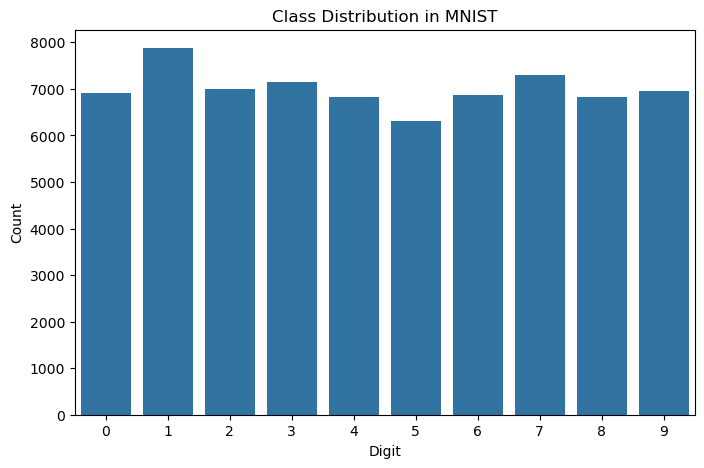

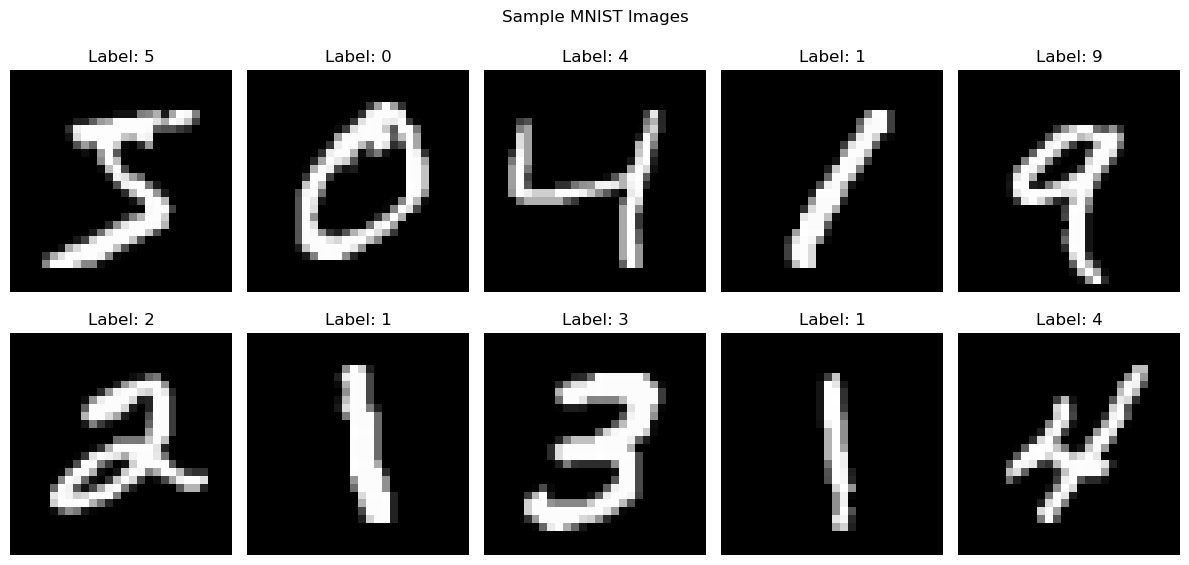

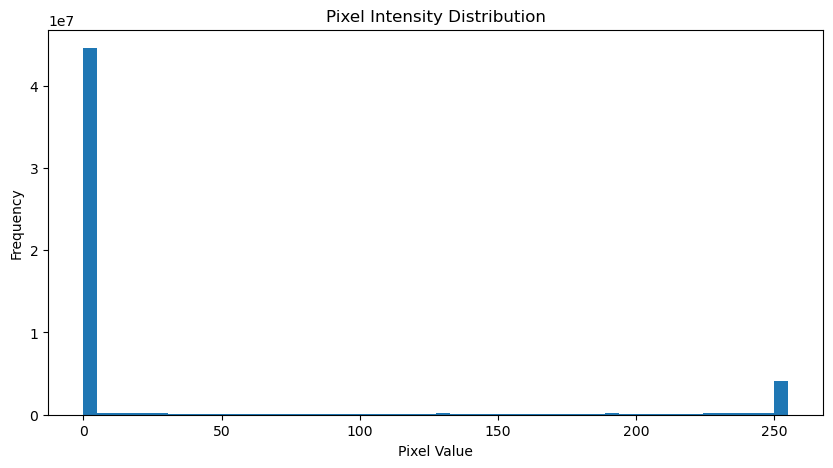


--- Pixel Statistics ---
Mean pixel value: 33.3860
Average pixel std deviation: 49.2554


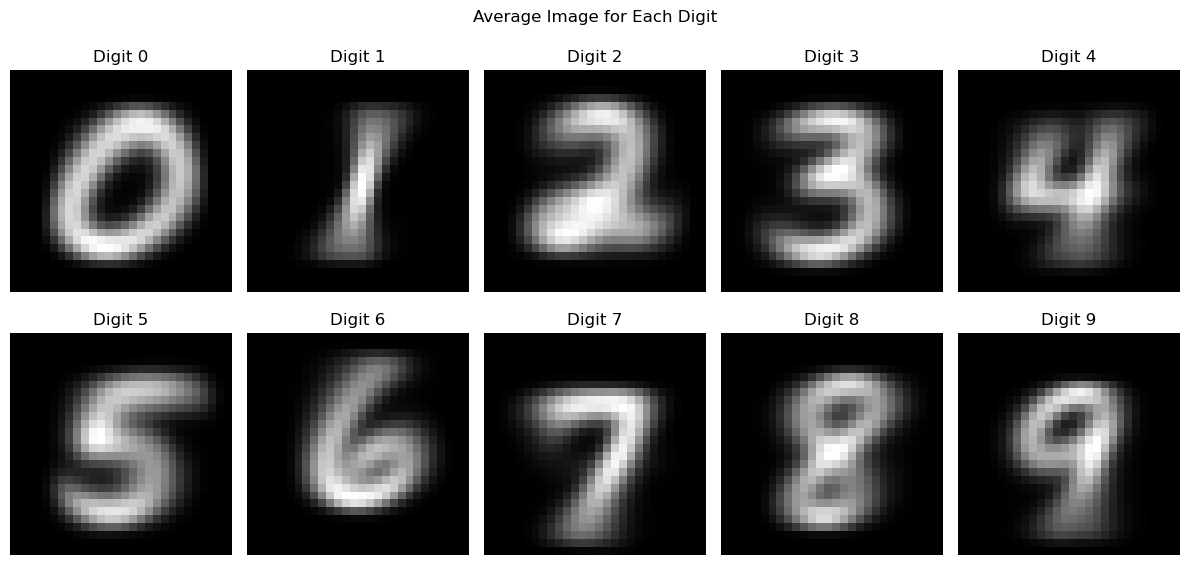


Generating digit correlation heatmap...


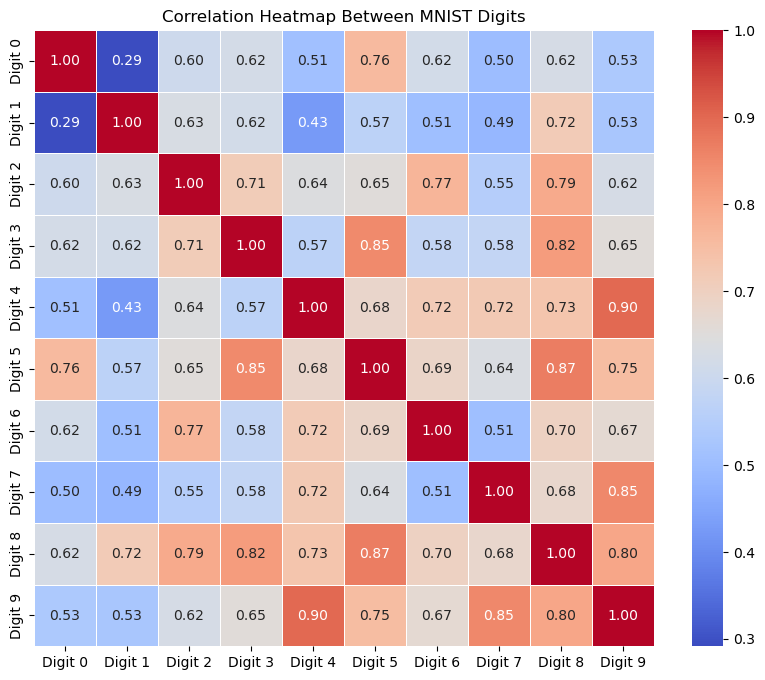


--- Summary Statistics ---
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value overall: 33.3860
Standard deviation overall: 78.6544

EDA Complete!


In [ ]:
# Exploratory Data Analysis (EDA) for the MNIST Dataset
# -----------------------------------------------------
# This script:
# 1. Loads the MNIST dataset
# 2. Explores dataset structure
# 3. Missing Values Check
# 4. Checks class distribution
# 5. Display Sample Images
# 6. Pixel Intensity Distribution
# 7. Mean and Standard Deviation of Pixels
# 8. Visualize Average Image per Digit
# 9. Correlation Heatmap between digits
# 10. Summary Statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# 1. Load MNIST Dataset
# -----------------------------------------------------
print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset loaded successfully!")

# -----------------------------------------------------
# 2. Basic Dataset Information
# -----------------------------------------------------
print("\n--- Dataset Information ---")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

print("\nUnique Classes:")
print(np.unique(y))

print("\nData Type:")
print(X.dtype)

# -----------------------------------------------------
# 3. Missing Values Check
# -----------------------------------------------------
print("\n--- Missing Values ---")
print(f"Total missing values: {np.isnan(X).sum()}")

# -----------------------------------------------------
# 4. Class Distribution
# -----------------------------------------------------
plt.figure(figsize=(8,5))
sns.countplot(x=y)
plt.title("Class Distribution in MNIST")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# -----------------------------------------------------
# 5. Display Sample Images
# -----------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 6. Pixel Intensity Distribution
# -----------------------------------------------------
plt.figure(figsize=(10,5))
plt.hist(X.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# -----------------------------------------------------
# 7. Mean and Standard Deviation of Pixels
# -----------------------------------------------------
pixel_means = np.mean(X, axis=0)
pixel_stds = np.std(X, axis=0)

print("\n--- Pixel Statistics ---")
print(f"Mean pixel value: {np.mean(pixel_means):.4f}")
print(f"Average pixel std deviation: {np.mean(pixel_stds):.4f}")

# -----------------------------------------------------
# 8. Visualize Average Image per Digit
# -----------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12,6))

digit_averages = []

for digit in range(10):

    avg_image = X[y == digit].mean(axis=0)
    digit_averages.append(avg_image)

    ax = axes[digit // 5, digit % 5]

    ax.imshow(avg_image.reshape(28, 28), cmap='gray')

    ax.set_title(f"Digit {digit}")
    ax.axis('off')

plt.suptitle("Average Image for Each Digit")

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 9. Correlation Heatmap between digits
# -----------------------------------------------------
print("\nGenerating digit correlation heatmap...")

digit_averages = np.array(digit_averages)

# Correlation matrix between average digit images
corr_matrix = np.corrcoef(digit_averages)

# Convert to dataframe for better labels
corr_df = pd.DataFrame(
    corr_matrix,
    index=[f"Digit {i}" for i in range(10)],
    columns=[f"Digit {i}" for i in range(10)]
)

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap Between MNIST Digits")

plt.show()


# -----------------------------------------------------
# 10. Summary Statistics
# -----------------------------------------------------
print("\n--- Summary Statistics ---")
print(f"Minimum pixel value: {X.min()}")
print(f"Maximum pixel value: {X.max()}")
print(f"Mean pixel value overall: {X.mean():.4f}")
print(f"Standard deviation overall: {X.std():.4f}")

print("\nEDA Complete!")